## IPL 2025 Capstone project

## 1. Introduction
The Indian premier league(IPL) is a professional T20 cricket in India, featuring franchises representing cities. This project explores IPL 2025 match- level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics .  

These are some of the important columns that we'll focus on for meaningful insights in this project. 

column names : Variable type 

- date : string
- venue : string
- stage : string
- team1 : string
- team2 : string
- toss_winner : string 
- toss_decision : string
- first_innings_score : integer 
- second_innings_score : integer 
- match_winner : string
- won_by : string
- margin : integer
- player_of_the_match : string
- top_scorer : string
- highscore : integer
- best_bowling_figure : string 

## 2. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')


##  Data Loading

In [3]:
IPL_data = pd.read_csv(r"C:\Users\acer\Downloads\merged_ipl_data.csv")
IPL_data.head()

,match_id,date,player_team,striker,batting_position,balls_faced,runs_scored,strike_rate,dots,singles,...,bowler,runs_conceded,wickets_taken,dots_bowled,fours_conceded,sixes_conceded,bowling_team,opposition_team,overs_bowled,economy_rate
0,202501,2025-03-22,KKR,de Kock,1.0,5.0,4.0,80.000000,4.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,202501,2025-03-22,KKR,Rahane,2.0,31.0,56.0,180.645161,14.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,202501,2025-03-22,KKR,Narine,3.0,26.0,44.0,169.230769,13.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,202501,2025-03-22,KKR,Venkatesh Iyer,4.0,7.0,6.0,85.714286,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,202501,2025-03-22,KKR,Angkrish Raghuvanshi,5.0,22.0,30.0,136.363636,4.0,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning

In [4]:
IPL_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1997 entries, 0 to 1996
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   match_id             1997 non-null   int64  
 1   date                 1991 non-null   str    
 2   player_team          1127 non-null   str    
 3   striker              1127 non-null   str    
 4   batting_position     1127 non-null   float64
 5   balls_faced          1127 non-null   float64
 6   runs_scored          1127 non-null   float64
 7   strike_rate          1127 non-null   float64
 8   dots                 1127 non-null   float64
 9   singles              1127 non-null   float64
 10  doubles              1127 non-null   float64
 11  triples              1127 non-null   float64
 12  fours                1127 non-null   float64
 13  fives                1127 non-null   float64
 14  sixes                1127 non-null   float64
 15  dismissal_type       1127 non-null   str    
 16 

check the size of rows and columns of the dataset

In [5]:
print(f"your rows are {IPL_data.shape[0]} and your columns are {IPL_data.shape[1]}")

your rows are 1997 and your columns are 36


 now lets see how many columns have null values in total.

In [6]:
IPL_data.isnull().sum()

match_id                  0
date                      6
player_team             870
striker                 870
batting_position        870
balls_faced             870
runs_scored             870
strike_rate             870
dots                    870
singles                 870
doubles                 870
triples                 870
fours                   870
fives                   870
sixes                   870
dismissal_type          870
date_match              872
venue                     8
team1                     8
team2                     8
stage                     8
match_winner             38
player_of_the_match      38
margin                   70
record_type               0
innings                1127
bowler                 1127
runs_conceded          1127
wickets_taken          1127
dots_bowled            1127
fours_conceded         1127
sixes_conceded         1127
bowling_team           1127
opposition_team        1127
overs_bowled           1127
economy_rate        

## Now Let's Check for Duplicate Records in the Dataset

In [7]:
IPL_data.duplicated().sum()

np.int64(0)

## Let's Explore the Dataset Statistics

In [8]:
IPL_data.describe()

,match_id,batting_position,balls_faced,runs_scored,strike_rate,dots,singles,doubles,triples,fours,fives,sixes,innings,runs_conceded,wickets_taken,dots_bowled,fours_conceded,sixes_conceded,overs_bowled,economy_rate
count,1997.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,870.000000,870.000000,870.000000,870.000000,870.000000,870.000000,870.000000,870.000000
mean,202536.954432,4.697427,14.656610,22.377107,131.978890,4.950311,5.669033,0.858917,0.024845,2.001775,0.001775,1.149956,1.506897,30.451724,1.003448,6.137931,2.621839,1.489655,3.151034,9.996084
std,21.575041,2.716279,12.727926,23.091769,78.074885,3.929125,5.907633,1.246155,0.161323,2.412224,0.042108,1.641399,0.509358,12.258131,1.043909,3.310451,1.753046,1.318806,1.028721,3.747506
min,202501.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.100000,2.000000
25%,202518.000000,2.000000,5.000000,4.000000,83.333333,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,22.000000,0.000000,4.000000,1.000000,0.000000,2.300000,7.500000
50%,202536.000000,4.000000,11.000000,15.000000,133.333333,4.000000,4.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,30.000000,1.000000,6.000000,2.000000,1.000000,3.750000,9.666667
75%,202556.000000,7.000000,21.500000,34.000000,178.319624,7.000000,8.000000,1.000000,0.000000,3.000000,0.000000,2.000000,2.000000,39.000000,2.000000,8.000000,4.000000,2.000000,4.000000,11.750000
max,202574.000000,11.000000,65.000000,141.000000,600.000000,21.000000,30.000000,8.000000,2.000000,14.000000,1.000000,11.000000,4.000000,80.000000,6.000000,17.000000,10.000000,7.000000,4.100000,54.000000


## Let's Check the Unique Teams in the Dataset

In [9]:
IPL_data['player_team'].unique()

<StringArray>
['KKR', 'RCB', 'SRH', 'RR', 'MI', 'CSK', 'LSG', 'DC', 'PBKS', 'GT', nan]
Length: 11, dtype: str

## Let's Check the Null Value Percentage

In [10]:
null_percent = (IPL_data.isnull().sum() / len(IPL_data)) * 100
null_percent.sort_values(ascending=False)

sixes_conceded         56.434652
fours_conceded         56.434652
dots_bowled            56.434652
wickets_taken          56.434652
runs_conceded          56.434652
innings                56.434652
bowler                 56.434652
overs_bowled           56.434652
bowling_team           56.434652
economy_rate           56.434652
opposition_team        56.434652
date_match             43.665498
strike_rate            43.565348
doubles                43.565348
player_team            43.565348
striker                43.565348
dots                   43.565348
batting_position       43.565348
runs_scored            43.565348
balls_faced            43.565348
fives                  43.565348
sixes                  43.565348
singles                43.565348
dismissal_type         43.565348
fours                  43.565348
triples                43.565348
margin                  3.505258
player_of_the_match     1.902854
match_winner            1.902854
team1                   0.400601
team2     

## Observation

The dataset contains missing values because batting and bowling records are stored in separate rows. These missing values are expected and will be handled during analysis.

## Let's Explore the Teams in IPL 2025

In [11]:
IPL_data['player_team'].dropna().unique()

<StringArray>
['KKR', 'RCB', 'SRH', 'RR', 'MI', 'CSK', 'LSG', 'DC', 'PBKS', 'GT']
Length: 10, dtype: str

## Number of Players Records by Team

In [12]:
match_df = IPL_data[['match_id','match_winner']].drop_duplicates()

In [13]:
match_df['match_winner'].value_counts()

match_winner
PBKS    11
RCB     10
GT       9
DC       8
MI       8
SRH      6
LSG      6
KKR      5
CSK      4
RR       4
Name: count, dtype: int64

 Now, Here comes some questions. 

### 4. Exploratory Data Analysis

# 1. Which Team Won the Most Matches in IPL 2025?

In [14]:
match_df['match_winner'].value_counts()

match_winner
PBKS    11
RCB     10
GT       9
DC       8
MI       8
SRH      6
LSG      6
KKR      5
CSK      4
RR       4
Name: count, dtype: int64

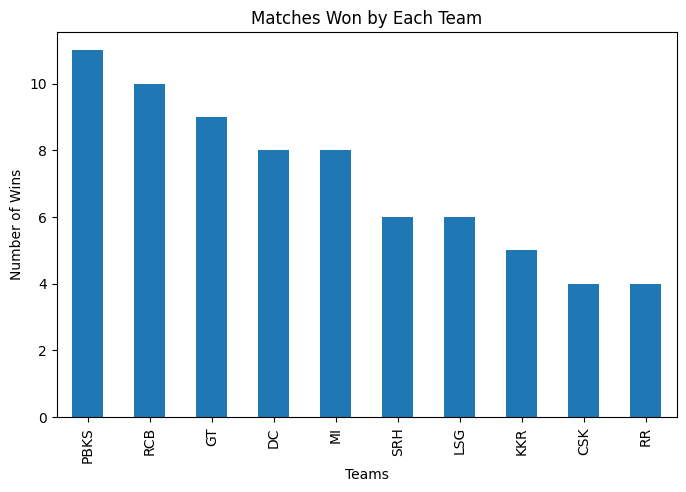

In [15]:
winner = match_df['match_winner'].value_counts()

plt.figure(figsize=(8,5))
winner.plot(kind='bar')
plt.title('Matches Won by Each Team')
plt.xlabel('Teams')
plt.ylabel('Number of Wins')
plt.show()

# 2 .most "player of the match" award .

In [16]:
match_df = IPL_data[['match_id', 'player_of_the_match']].drop_duplicates()

In [17]:
match_df.head()

,match_id,player_of_the_match
0,202501,Krunal Pandya
15,202502,Ishan Kishan
31,202503,Noor Ahmad
50,202504,Ashutosh Sharma
70,202505,Shreyas Iyer


In [18]:
count = match_df['player_of_the_match'].value_counts().head(10)

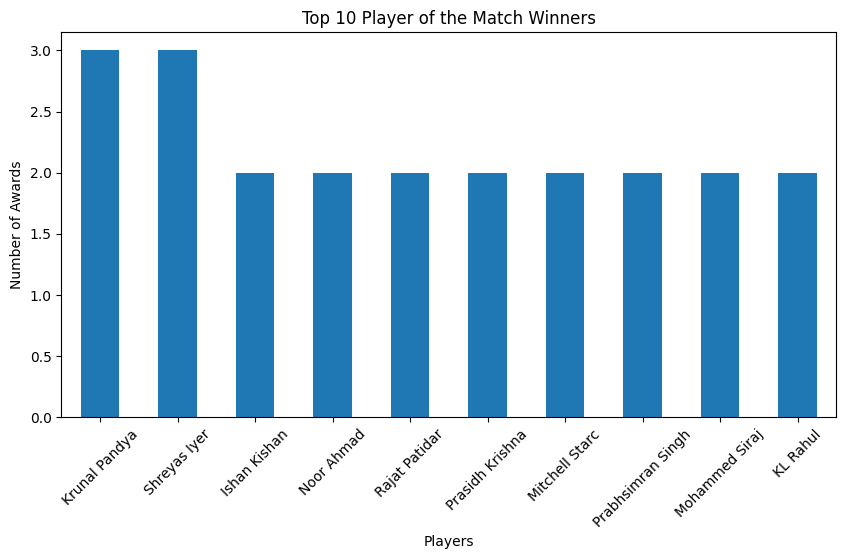

In [19]:
plt.figure(figsize=(10,5))

count.plot(kind= 'bar')

plt.title('Top 10 Player of the Match Winners')
plt.xlabel('Players')
plt.ylabel('Number of Awards')

plt.xticks(rotation=45)

plt.show()

# 3.  Who Were the Top 10 Run Scorers in IPL 2025?

In [20]:
top_runs = IPL_data.groupby('striker')['runs_scored'].sum().sort_values(ascending=False).head(10)
top_runs

striker
Sai Sudharsan       759.0
Suryakumar Yadav    717.0
Kohli               657.0
Shubman Gill        649.0
Mitchell Marsh      627.0
Shreyas Iyer        603.0
Prabhsimran         598.0
Jaiswal             559.0
Rahul               546.0
Priyansh Arya       545.0
Name: runs_scored, dtype: float64

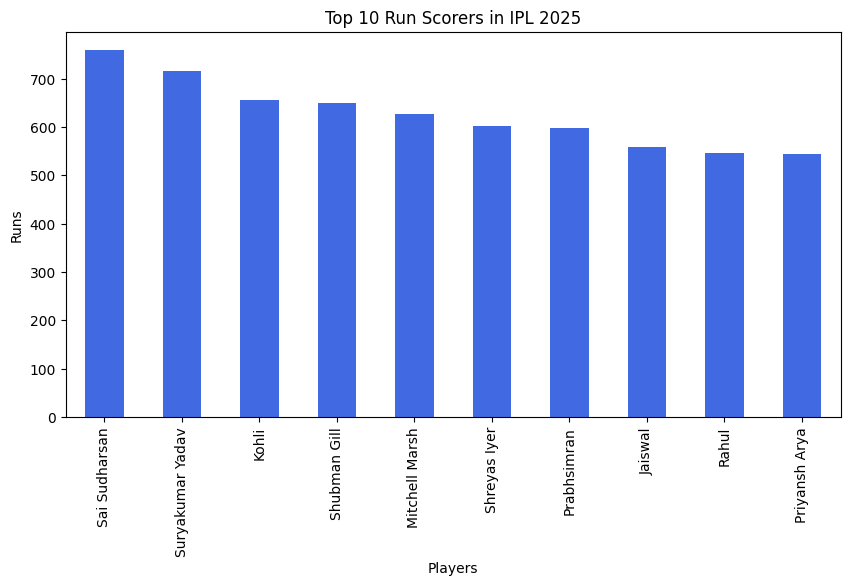

In [21]:
plt.figure(figsize=(10,5))
top_runs.plot(kind='bar', color='royalblue')
plt.title('Top 10 Run Scorers in IPL 2025')
plt.xlabel('Players')
plt.ylabel('Runs')
plt.show()

### Observation

The analysis shows the top 10 run scorers of IPL 2025. These players consistently contributed with the bat and played a crucial role for their teams throughout the tournament.

## 4.  Who Were the Top 10 Wicket Takers in IPL 2025?

In [22]:
top_wickets = IPL_data.groupby('bowler')['wickets_taken'].sum().sort_values(ascending=False).head(10)

top_wickets

bowler
Prasidh           26.0
Noor Ahmad        24.0
Boult             23.0
Hazlewood         22.0
Arshdeep Singh    22.0
Bumrah            21.0
Vaibhav Arora     19.0
Mitchell Starc    19.0
Sai Kishore       19.0
Bhuvneshwar       18.0
Name: wickets_taken, dtype: float64

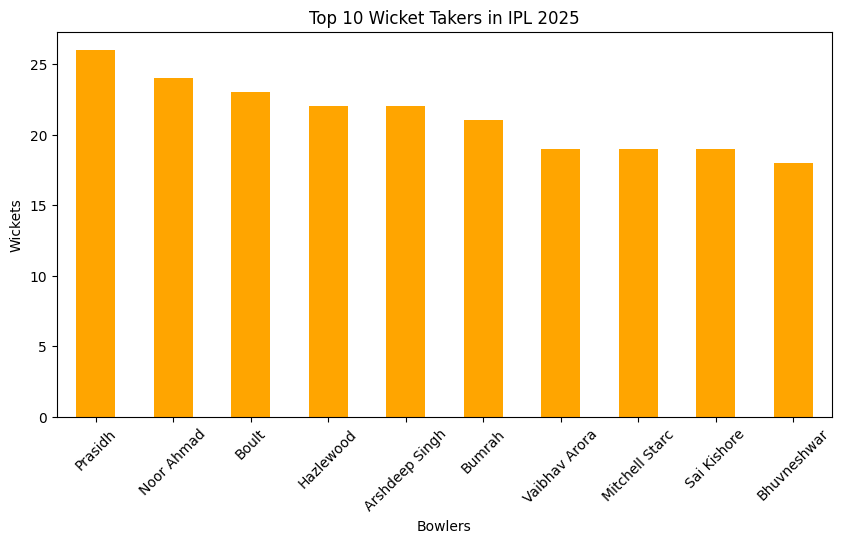

In [23]:
plt.figure(figsize=(10,5))

top_wickets.plot(kind='bar', color='orange')

plt.title('Top 10 Wicket Takers in IPL 2025')
plt.xlabel('Bowlers')
plt.ylabel('Wickets')

plt.xticks(rotation=45)

plt.show()

### Observation

The graph highlights the top 10 wicket takers in IPL 2025. The leading bowlers consistently picked up wickets and played a crucial role in restricting opposition teams. Their performances significantly contributed to their team's success throughout the tournament.

## 5.   Which Team Scored the Most Runs in IPL 2025?

In [24]:
team_runs = IPL_data.groupby('player_team')['runs_scored'].sum().sort_values(ascending=False)
team_runs

player_team
PBKS    3117.0
MI      2793.0
GT      2763.0
LSG     2583.0
RCB     2515.0
RR      2506.0
DC      2386.0
SRH     2373.0
CSK     2299.0
KKR     1884.0
Name: runs_scored, dtype: float64

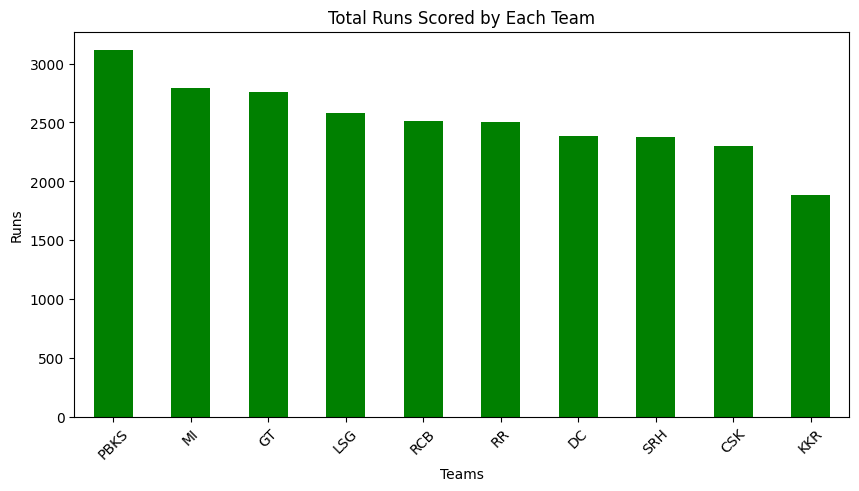

In [25]:
plt.figure(figsize=(10,5))

team_runs.plot(kind='bar', color='green')

plt.title('Total Runs Scored by Each Team')
plt.xlabel('Teams')
plt.ylabel('Runs')

plt.xticks(rotation=45)

plt.show()

### Observation

The graph shows the total runs scored by each team during IPL 2025. The team at the top accumulated the highest number of runs, indicating a strong batting performance throughout the tournament.

## 6.  Which Team Took the Most Wickets in IPL 2025?

In [26]:
team_wickets = IPL_data.groupby('bowling_team')['wickets_taken'].sum().sort_values(ascending=False)

team_wickets

bowling_team
MI      116.0
PBKS     97.0
RCB      94.0
GT       88.0
SRH      88.0
CSK      83.0
KKR      81.0
LSG      80.0
DC       76.0
RR       70.0
Name: wickets_taken, dtype: float64

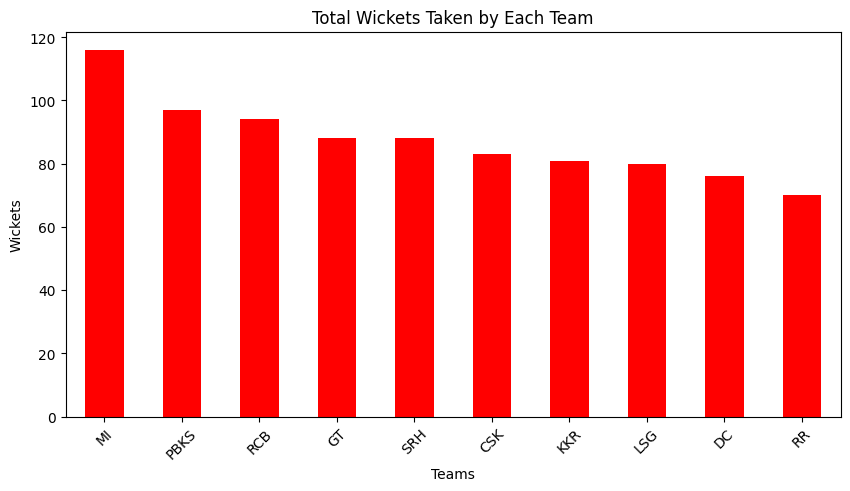

In [27]:
plt.figure(figsize=(10,5))

team_wickets.plot(kind='bar', color='red')

plt.title('Total Wickets Taken by Each Team')
plt.xlabel('Teams')
plt.ylabel('Wickets')

plt.xticks(rotation=45)

plt.show()

### Observation

The graph highlights the wicket-taking performance of each team in IPL 2025. Teams with a higher wicket count demonstrated stronger bowling performances throughout the season.

## 7. Which Venue Hosted the Most Matches in IPL 2025?

In [28]:
match_df = IPL_data[['match_id','venue']].drop_duplicates()

venue_count = match_df['venue'].value_counts()

venue_count

venue
Narendra Modi Stadium, Ahmedabad                 9
Ekana Cricket Stadium, Lucknow                   8
Eden Gardens, Kolkata                            7
Wankhede Stadium, Mumbai                         7
Sawai Mansingh Stadium, Jaipur                   7
Arun Jaitley Stadium, Delhi                      7
Rajiv Gandhi International Stadium, Hyderabad    6
MA Chidambaram Stadium, Chennai                  6
New PCA Cricket Stadium, Mullanpur               6
M. Chinnaswamy Stadium, Bangalore                5
ACA-VDCA Cricket Stadium, Vishakhapatnam         2
Barsapara Stadium, Guwahati                      2
HPCA Stadium, Dharamshala                        1
Name: count, dtype: int64

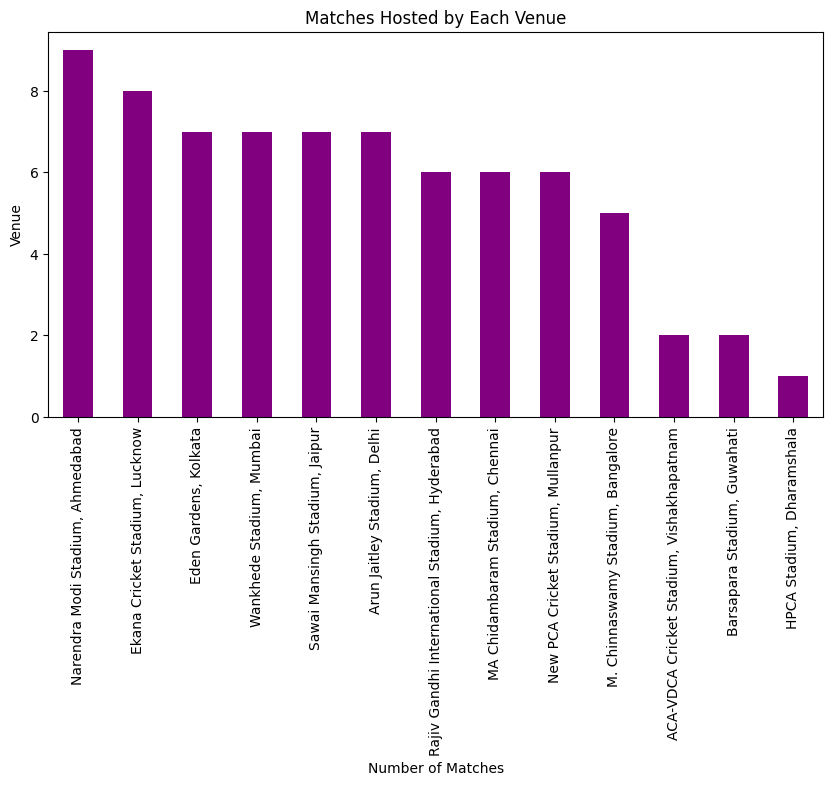

In [29]:
plt.figure(figsize=(10,5))

venue_count.plot(kind='bar', color='purple')

plt.title('Matches Hosted by Each Venue')
plt.ylabel('Venue')
plt.xlabel('Number of Matches')

plt.xticks(rotation=90)

plt.show()

### Observation

The graph shows the number of matches hosted by each venue during IPL 2025. The venue with the highest count hosted the most matches throughout the tournament.

# Conclusion

This IPL 2025 analysis explored team performances, player performances, venue statistics, and match outcomes. The analysis identified the top run scorers, leading wicket takers, most successful teams, and key match-winning players. These insights provide a comprehensive overview of the IPL 2025 season and highlight the factors that contributed to team and player success.

# Key Insights

1. The team with the highest number of wins emerged as the most successful team of IPL 2025.

2. The leading run scorer consistently contributed with the bat and played a crucial role for their team.

3. The top wicket taker was highly effective in restricting opposition teams.

4. Player of the Match analysis highlighted the most impactful players of the tournament.

5. Venue analysis revealed which stadiums hosted the maximum number of matches.

6. Team-wise batting and bowling analysis helped compare overall team performances throughout the season.

## Thank You